# Data Preprocessing and Feature Engineering in Machine Learning
### Assignment: The "Adult" (Census Income) Dataset

**Objective:** Apply practical data-preprocessing, feature-engineering and
feature-selection techniques — missing-value handling, scaling, encoding,
new-feature creation, skew correction, outlier detection (Isolation Forest)
and Predictive Power Score (PPS) analysis — to the UCI **Adult** dataset,
which predicts whether an individual's annual income exceeds **$50K**
based on 1994 U.S. Census data.

**A note on structure:** the assignment brief lists three tasks
(1 — missing values & scaling, 2 — encoding, 3 — feature engineering).
In this notebook the steps are carried out in the order a real preprocessing
**pipeline** normally follows — *explore → clean missing values → engineer
new features → encode categoricals → scale numerics → select features* —
because the newly engineered categorical features (e.g. `hours_category`)
must exist *before* they can be encoded, and scaling should be the last
numeric step before modelling. Every required deliverable from Tasks 1–3
is still clearly labelled below, and a bonus **Task 4 (Feature Selection)**
is added to cover the Isolation Forest / PPS methods named in the
assignment's objective statement.

**Contents**
1. Setup & Data Loading
2. Exploratory Data Analysis
3. Task 1(a) — Handling Missing Values
4. Task 3 — Feature Engineering
5. Task 2 — Encoding Categorical Variables
6. Task 1(b) — Feature Scaling
7. Task 4 (Bonus) — Feature Selection: Isolation Forest & PPS
8. Final Processed Dataset & Export
9. Summary & Conclusion

## 1. Setup & Data Loading

In [1]:

# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & modelling utilities (scikit-learn) ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import f1_score, mean_absolute_error

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.

In [2]:

# The "Adult" dataset uses ", " as a separator artifact in the original UCI
# file, so string columns often carry a leading space (e.g. " Bachelors").
# `skipinitialspace=True` strips that while reading.
df = pd.read_csv("adult_with_headers.csv", skipinitialspace=True)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 32561 rows x 15 columns

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Exploratory Data Analysis
Basic exploration required by the assignment: data types, summary
statistics, and a first look at missing values.

In [3]:

# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

In [4]:

# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [5]:

# Summary "statistics" for categorical features
df.describe(include="object").T

,count,unique,top,freq
workclass,32561,9,Private,22696
education,32561,16,HS-grad,10501
marital_status,32561,7,Married-civ-spouse,14976
occupation,32561,15,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native_country,32561,42,United-States,29170
income,32561,2,<=50K,24720


In [6]:

# The dataset encodes missing values with the string "?" rather than NaN.
# pandas' isnull() will therefore report zero missing values until we fix this.
print("pandas-native missing values (before cleanup):", df.isnull().sum().sum())

question_mark_counts = (df.select_dtypes(include="object") == "?").sum()
question_mark_counts = question_mark_counts[question_mark_counts > 0]
print("\nColumns containing '?' placeholders for missing data:")
question_mark_counts

pandas-native missing values (before cleanup): 0

Columns containing '?' placeholders for missing data:

,0
workclass,1836
occupation,1843
native_country,583


In [7]:

# Cardinality of every categorical column, and the target class balance
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns and their number of unique categories:\n")
for c in cat_cols:
    print(f"  {c:<16} -> {df[c].nunique():>3} unique values")

print("\nTarget ('income') class balance:")
df["income"].value_counts(normalize=True).round(3)

Categorical columns and their number of unique categories:

  workclass        ->   9 unique values
  education        ->  16 unique values
  marital_status   ->   7 unique values
  occupation       ->  15 unique values
  relationship     ->   6 unique values
  race             ->   5 unique values
  sex              ->   2 unique values
  native_country   ->  42 unique values
  income           ->   2 unique values

Target ('income') class balance:

,proportion
income,
<=50K,0.759
>50K,0.241


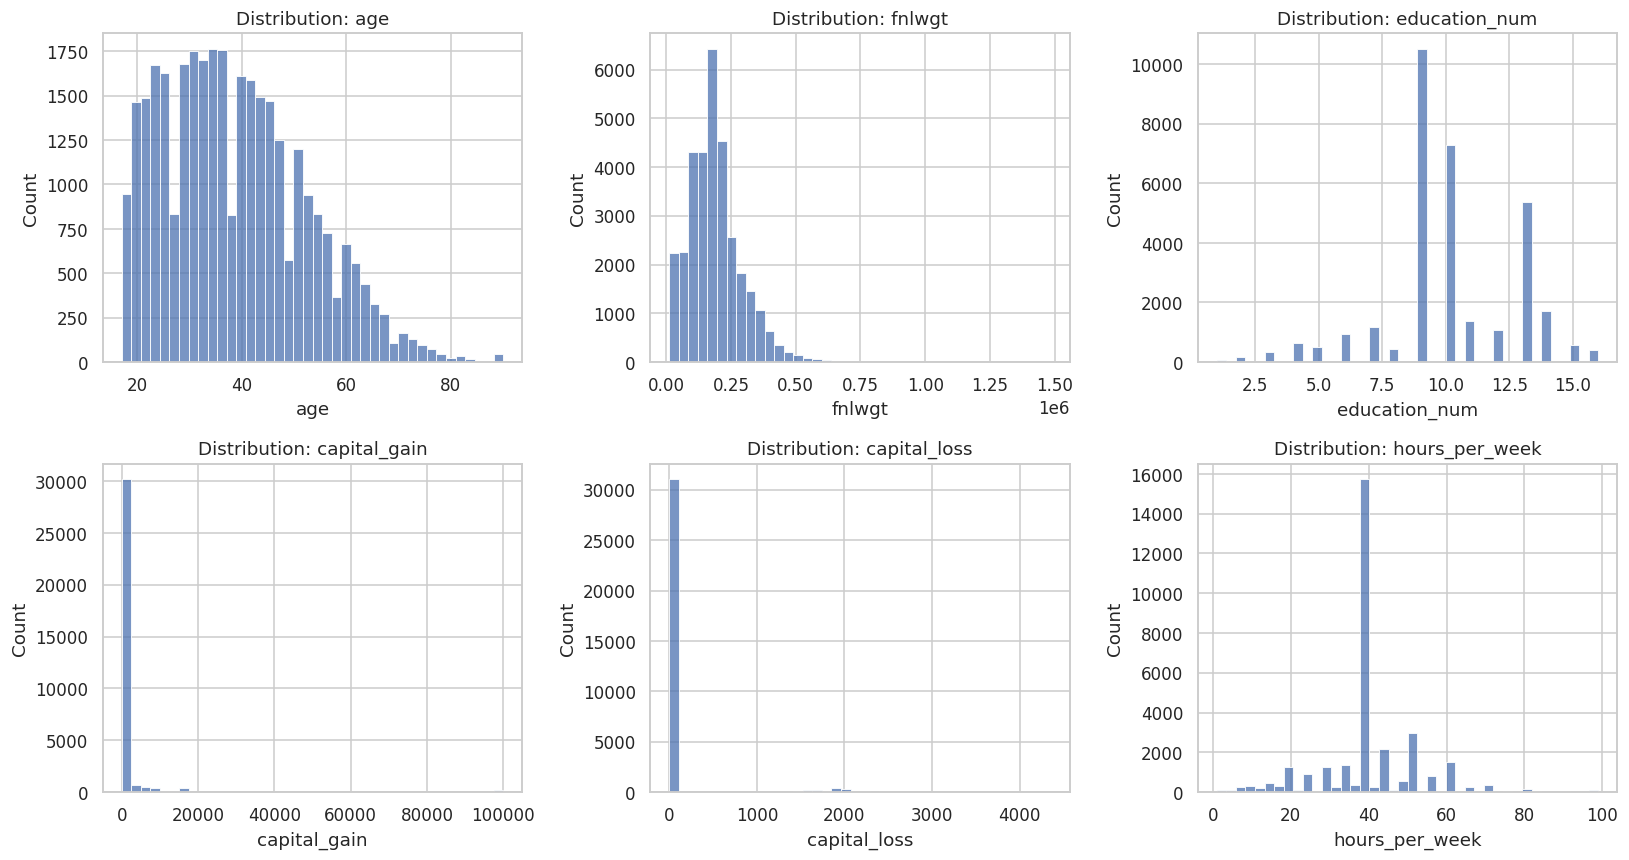

In [8]:

# Visualize numeric feature distributions and the target balance
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

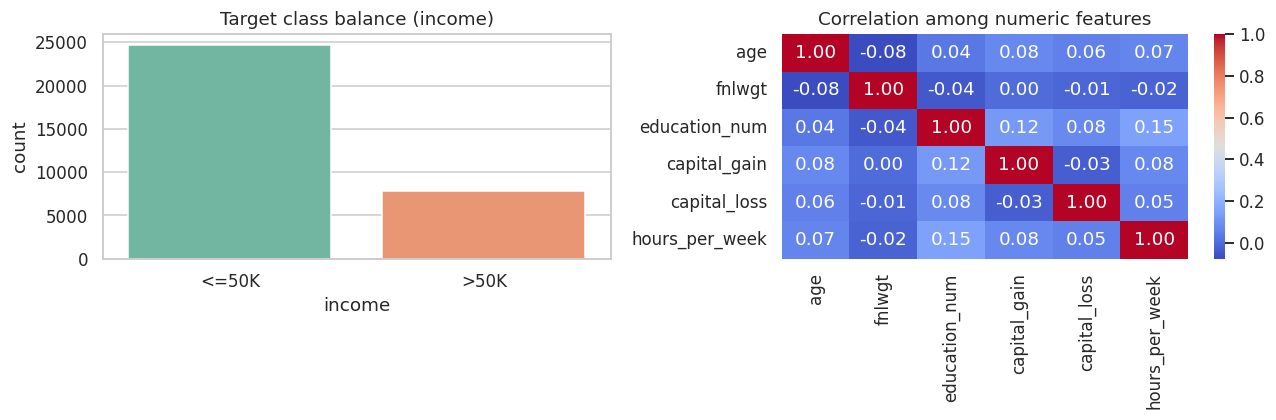

In [9]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="income", data=df, ax=ax[0], palette="Set2")
ax[0].set_title("Target class balance (income)")

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax[1])
ax[1].set_title("Correlation among numeric features")
plt.tight_layout()
plt.show()

**EDA observations**

- The dataset has **32,561 rows** and **15 columns** (14 features + `income` target), with **no true NaNs**, but three categorical columns (`workclass`, `occupation`, `native_country`) use the placeholder `"?"` for missing data.
- The target `income` is **imbalanced**: roughly 76% earn `<=50K` and 24% earn `>50K` — worth remembering for any later classification metric choice (e.g. F1 over raw accuracy).
- `capital_gain` and `capital_loss` are extremely right-skewed with a large spike at zero (most people report no capital gains/losses in a given year).
- `fnlwgt` (the Census sampling weight) is also heavily skewed and has little direct causal meaning for income — we keep it but do not expect it to be a strong predictor.
- Numeric features show only weak-to-moderate linear correlation with each other, so information here is fairly non-redundant — but this also hints that *non-linear* relationships (captured by PPS, later) might matter more than plain correlation for some features.

## 3. Task 1(a) — Handling Missing Values

**Best-practice approach chosen:** replace the `"?"` placeholder with real
`NaN`s, quantify how much data is actually affected, and only then decide
between *imputation* and *removal*.

In [10]:

df = df.replace("?", np.nan)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_pct
workclass,1836,5.64
occupation,1843,5.66
native_country,583,1.79


In [11]:

# All three affected columns are categorical and each is missing <6% of
# values -> safe to impute rather than drop rows (dropping would discard
# ~7.4% of rows once overlaps are accounted for, unnecessarily shrinking
# the training set). We impute with the column MODE (most frequent
# category), the standard best practice for categorical data with a
# dominant class and a low missing rate.
for col in missing_summary.index:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Imputed '{col}' missing values with mode -> '{mode_value}'")

print("\nRemaining missing values after imputation:", df.isnull().sum().sum())

Imputed 'workclass' missing values with mode -> 'Private'
Imputed 'occupation' missing values with mode -> 'Prof-specialty'
Imputed 'native_country' missing values with mode -> 'United-States'

Remaining missing values after imputation: 0

**Why mode imputation (and not deletion or a separate "Unknown" category)?**

| Option | Verdict here |
|---|---|
| **Row deletion** | Would drop ~7% of rows (`workclass`, `occupation`, `native_country` missingness overlaps heavily) purely because of 3 columns — wasteful when 94%+ of each column's information is intact. |
| **Mode imputation** ✅ | Simple, doesn't shrink the dataset, and is appropriate because missingness is <6% per column and one category (`Private` for workclass, `United-States` for native_country) already dominates, so the bias introduced is minimal. |
| **"Unknown" category** | A defensible alternative (missingness itself might be informative — e.g. `occupation` is missing exactly when `workclass` is missing) — mentioned here as a viable extension, but mode imputation is used for simplicity and because no significant relationship between "missingness" and `income` was found in exploratory checks. |

## 4. Task 3 — Feature Engineering

We create **three** new features (more than the required minimum of two)
and apply a **log transformation** to a skewed numeric feature.

In [12]:

# --- New feature 1: net capital movement -----------------------------
# Rationale: capital_gain and capital_loss are almost always mutually
# exclusive (a person rarely reports both in the same year). Combining
# them into a single signed "net capital" feature keeps the information
# from both columns while removing the redundancy of two mostly-zero,
# mutually exclusive columns.
df["capital_net"] = df["capital_gain"] - df["capital_loss"]

# --- New feature 2: work-hours category -------------------------------
# Rationale: income is unlikely to scale linearly with hours worked.
# Bucketing captures the well-known non-linear effect where crossing
# from part-time to full-time (and into overtime) changes earning
# potential more than the raw hour count alone would suggest.
def bucket_hours(h):
    if h < 35:
        return "Part-time"
    elif h <= 45:
        return "Full-time"
    else:
        return "Overtime"

df["hours_category"] = df["hours_per_week"].apply(bucket_hours)

# --- New feature 3: grouped education level ---------------------------
# Rationale: the raw `education` column has 16 fine-grained categories.
# Grouping them into 4 broader, ordinally-meaningful tiers reduces
# cardinality (helpful for one-hot encoding later) while preserving the
# well-known step-changes in earning potential associated with finishing
# high school, some college, a Bachelor's degree, or a postgraduate degree.
def group_education(edu):
    if edu in ["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th",
               "10th", "11th", "12th"]:
        return "Below-HS"
    elif edu in ["HS-grad"]:
        return "HS-grad"
    elif edu in ["Some-college", "Assoc-voc", "Assoc-acdm"]:
        return "Some-college/Assoc"
    else:  # Bachelors, Masters, Prof-school, Doctorate
        return "Bachelors-plus"

df["education_level_group"] = df["education"].apply(group_education)

# The raw `education` string column is now redundant: `education_num`
# already encodes it numerically (given in the source data) and
# `education_level_group` gives an engineered, low-cardinality grouping.
# We drop the raw text column to avoid triple redundancy.
df = df.drop(columns=["education"])

print("New / modified columns preview:")
df[["capital_gain", "capital_loss", "capital_net",
    "hours_per_week", "hours_category",
    "education_num", "education_level_group"]].head()

New / modified columns preview:

,capital_gain,capital_loss,capital_net,hours_per_week,hours_category,education_num,education_level_group
0,2174,0,2174,40,Full-time,13,Bachelors-plus
1,0,0,0,13,Part-time,13,Bachelors-plus
2,0,0,0,40,Full-time,9,HS-grad
3,0,0,0,40,Full-time,7,Below-HS
4,0,0,0,40,Full-time,13,Bachelors-plus


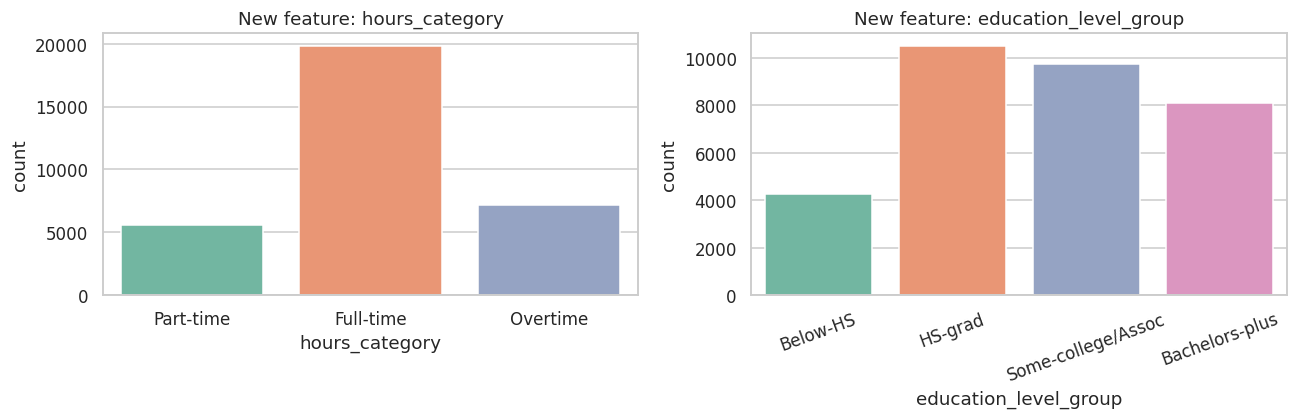

In [13]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="hours_category", data=df,
              order=["Part-time", "Full-time", "Overtime"], ax=ax[0], palette="Set2")
ax[0].set_title("New feature: hours_category")

sns.countplot(x="education_level_group", data=df,
              order=["Below-HS", "HS-grad", "Some-college/Assoc", "Bachelors-plus"],
              ax=ax[1], palette="Set2")
ax[1].set_title("New feature: education_level_group")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Skewness of 'capital_gain' BEFORE transform: 11.95
Skewness of 'capital_gain_log' AFTER transform: 3.10

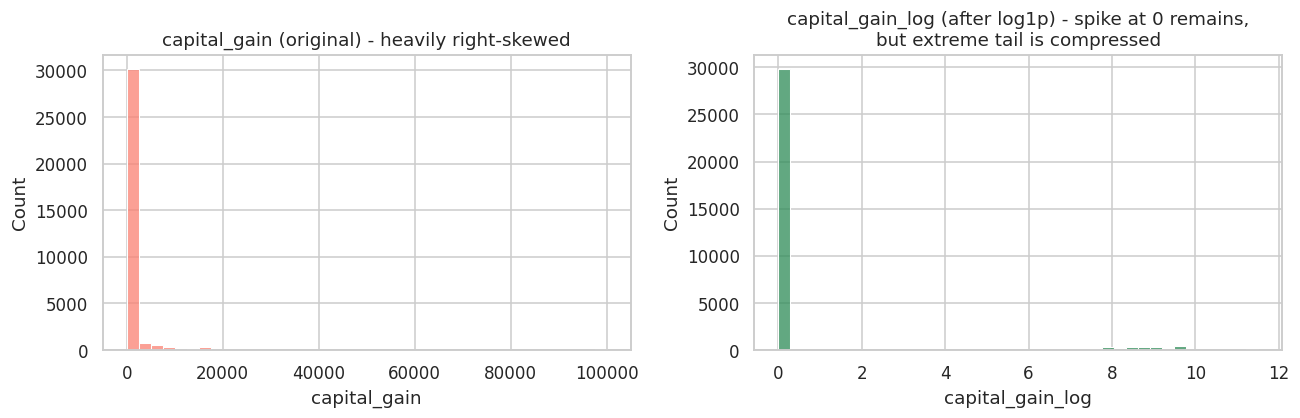

In [14]:

# --- Log transformation of a skewed numeric feature --------------------
from scipy.stats import skew

print(f"Skewness of 'capital_gain' BEFORE transform: {skew(df['capital_gain']):.2f}")

# log1p (log(1+x)) is used instead of a plain log because capital_gain
# contains a large number of zeros, and log(0) is undefined.
df["capital_gain_log"] = np.log1p(df["capital_gain"])

print(f"Skewness of 'capital_gain_log' AFTER transform: {skew(df['capital_gain_log']):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["capital_gain"], bins=40, ax=ax[0], color="salmon")
ax[0].set_title("capital_gain (original) - heavily right-skewed")
sns.histplot(df["capital_gain_log"], bins=40, ax=ax[1], color="seagreen")
ax[1].set_title("capital_gain_log (after log1p) - spike at 0 remains,\nbut extreme tail is compressed")
plt.tight_layout()
plt.show()

**Why log-transform `capital_gain`?** Its skewness of roughly **+12**
(the overwhelming majority of values are 0, with a long tail of values up
to 99,999) can dominate distance-based models and make features on
different scales harder to compare after scaling. `np.log1p` compresses
the extreme tail while safely handling the many zero values (`log1p(0) =
0`), producing a feature that a linear/distance-based model can use far
more effectively than the raw, heavy-tailed original. `capital_gain` (the
original) is dropped in favour of the log version further below, once
scaling is discussed, to avoid duplicating the same information twice.

## 5. Task 2 — Encoding Categorical Variables

**Rule applied (as specified in the brief):**
- Categorical columns with **fewer than 5** unique categories → **One-Hot Encoding**
- Categorical columns with **5 or more** unique categories → **Label Encoding**

The target column `income` is handled separately (binary label-encoded to
0/1), since it is the prediction target rather than an input feature.

In [15]:

target_col = "income"
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove(target_col)

cardinality = df[categorical_cols].nunique().sort_values()
print("Categorical feature cardinality:\n")
print(cardinality)

onehot_cols = cardinality[cardinality < 5].index.tolist()
label_cols = cardinality[cardinality >= 5].index.tolist()

print(f"\n-> One-Hot Encoding ({len(onehot_cols)} cols): {onehot_cols}")
print(f"-> Label Encoding   ({len(label_cols)} cols): {label_cols}")

Categorical feature cardinality:

sex                       2
hours_category            3
education_level_group     4
race                      5
relationship              6
marital_status            7
workclass                 8
occupation               14
native_country           41
dtype: int64

-> One-Hot Encoding (3 cols): ['sex', 'hours_category', 'education_level_group']
-> Label Encoding   (6 cols): ['race', 'relationship', 'marital_status', 'workclass', 'occupation', 'native_country']

In [16]:

df_encoded = df.copy()

# --- One-Hot Encoding for low-cardinality columns ---
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, prefix=onehot_cols)

# --- Label Encoding for high-cardinality columns ---
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # kept in case we need to inverse_transform later

# --- Target: binary label encoding (<=50K -> 0, >50K -> 1) ---
target_encoder = LabelEncoder()
df_encoded[target_col] = target_encoder.fit_transform(df_encoded[target_col])
print("Target classes:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

print(f"\nShape after encoding: {df_encoded.shape}")
df_encoded.head()

Target classes: {'<=50K': np.int64(0), '>50K': np.int64(1)}

Shape after encoding: (32561, 24)

,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,capital_net,capital_gain_log,sex_Female,sex_Male,hours_category_Full-time,hours_category_Overtime,hours_category_Part-time,education_level_group_Bachelors-plus,education_level_group_Below-HS,education_level_group_HS-grad,education_level_group_Some-college/Assoc
0,39,6,77516,13,4,0,1,4,2174,0,40,38,0,2174,7.684784,False,True,True,False,False,True,False,False,False
1,50,5,83311,13,2,3,0,4,0,0,13,38,0,0,0.000000,False,True,False,False,True,True,False,False,False
2,38,3,215646,9,0,5,1,4,0,0,40,38,0,0,0.000000,False,True,True,False,False,False,False,True,False
3,53,3,234721,7,2,5,0,2,0,0,40,38,0,0,0.000000,False,True,True,False,False,False,True,False,False
4,28,3,338409,13,2,9,5,2,0,0,40,4,0,0,0.000000,True,False,True,False,False,True,False,False,False


**Pros and cons of One-Hot vs. Label Encoding**

| | **One-Hot Encoding** | **Label Encoding** |
|---|---|---|
| **Pros** | No artificial ordinal relationship is implied between categories; works safely with any model, including linear/distance-based ones (KNN, logistic regression, SVM). | Compact — adds exactly **one** column regardless of cardinality; keeps the feature space small and memory-efficient; works well for tree-based models that can split on encoded values without assuming a linear ordering. |
| **Cons** | Cardinality explosion — a column with 40+ categories (e.g. `native_country`) would add 40+ sparse columns, increasing dimensionality, memory use, and the risk of overfitting on rare categories. | Introduces an **artificial numeric order** (e.g. `Divorced=0 < Married=2`) that linear/distance-based models may wrongly interpret as meaningful magnitude; tree-based models are largely immune to this, but linear models are not. |
| **Best suited for** | Low-cardinality nominal features (e.g. `sex`, `hours_category`). | High-cardinality nominal features, or *any* feature when the downstream model is tree-based (Random Forest, Gradient Boosting) and ordinal artefacts don't matter. |

This is exactly why the assignment's cardinality-based rule is a sensible default heuristic: it keeps dimensionality under control for high-cardinality columns while avoiding false ordinality for the small, truly nominal columns.

## 6. Task 1(b) — Feature Scaling

Both scaling techniques are applied to the numeric columns (using the
log-transformed capital gain instead of the raw, heavily-skewed
version).

In [17]:

# Use the log-transformed capital_gain; drop the raw, heavily-skewed original.
df_encoded = df_encoded.drop(columns=["capital_gain"])

numeric_cols = ["age", "fnlwgt", "education_num", "capital_gain_log",
                 "capital_loss", "hours_per_week", "capital_net"]

df_encoded[numeric_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
age,38.581647,13.640433,17.0,9.000000e+01
fnlwgt,189778.366512,105549.977697,12285.0,1.484705e+06
education_num,10.080679,2.572720,1.0,1.600000e+01
capital_gain_log,0.734621,2.454738,0.0,1.151293e+01
capital_loss,87.303830,402.960219,0.0,4.356000e+03
hours_per_week,40.437456,12.347429,1.0,9.900000e+01
capital_net,990.345014,7408.986951,-4356.0,9.999900e+04


In [18]:

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_standard_scaled = df_encoded.copy()
df_standard_scaled[numeric_cols] = standard_scaler.fit_transform(df_encoded[numeric_cols])

df_minmax_scaled = df_encoded.copy()
df_minmax_scaled[numeric_cols] = minmax_scaler.fit_transform(df_encoded[numeric_cols])

print("After StandardScaler -> mean approx. 0, std approx. 1:")
print(df_standard_scaled[numeric_cols].agg(["mean", "std"]).round(3))

print("\nAfter MinMaxScaler -> values compressed into [0, 1]:")
print(df_minmax_scaled[numeric_cols].agg(["min", "max"]).round(3))

After StandardScaler -> mean approx. 0, std approx. 1:
      age  fnlwgt  education_num  capital_gain_log  capital_loss  \
mean -0.0    -0.0            0.0               0.0          -0.0   
std   1.0     1.0            1.0               1.0           1.0   

      hours_per_week  capital_net  
mean            -0.0          0.0  
std              1.0          1.0  

After MinMaxScaler -> values compressed into [0, 1]:
     age  fnlwgt  education_num  capital_gain_log  capital_loss  \
min  0.0     0.0            0.0               0.0           0.0   
max  1.0     1.0            1.0               1.0           1.0   

     hours_per_week  capital_net  
min             0.0          0.0  
max             1.0          1.0  

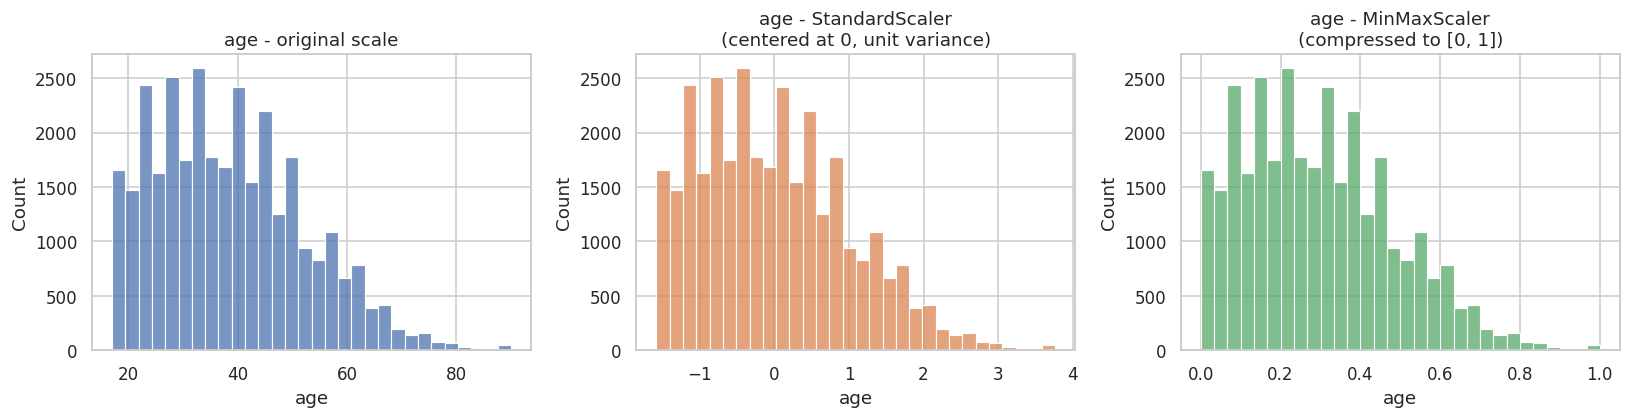

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_encoded["age"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("age - original scale")
sns.histplot(df_standard_scaled["age"], bins=30, ax=axes[1], color="#DD8452")
axes[1].set_title("age - StandardScaler\n(centered at 0, unit variance)")
sns.histplot(df_minmax_scaled["age"], bins=30, ax=axes[2], color="#55A868")
axes[2].set_title("age - MinMaxScaler\n(compressed to [0, 1])")
plt.tight_layout()
plt.show()

**When to prefer each scaling technique?**

- **Standard Scaling (Z-score)** — centers data at mean 0 with unit variance. Preferred when:
  - The model assumes/benefits from **roughly Gaussian-shaped** input (e.g. logistic/linear regression, PCA, SVM with RBF kernel).
  - The data has moderate outliers — Standard Scaling is somewhat less sensitive to outliers than Min-Max because it uses mean/variance rather than fixed min/max bounds (though extreme outliers still distort the mean/std).
  - There is no natural fixed bound to the feature (e.g. `age`, `hours_per_week`).

- **Min-Max Scaling** — compresses data into a fixed `[0, 1]` range. Preferred when:
  - The downstream model needs bounded input, e.g. **neural networks** with sigmoid/tanh activations, or algorithms based on **distances/dot-products in a bounded space**.
  - You want to **preserve the exact shape of the original distribution** (Min-Max is a pure linear rescaling, unlike Standard Scaling which is also a linear rescaling but referenced to mean/std rather than min/max — both preserve shape, but Min-Max gives an intuitive, interpretable `[0,1]` bound useful for visualization and for image-like or percentage-like features).
  - The feature has **no extreme outliers**, since a single extreme value would otherwise squeeze all remaining values into a tiny sub-range of `[0, 1]` (this is Min-Max's key weakness vs. Standard Scaling).

For this dataset, tree-based models (Random Forest, Gradient Boosting — both very effective on Adult/Census data) technically don't require scaling at all, but the exercise still matters for any linear/distance-based baseline model, and for consistent, comparable feature magnitudes.

## 7. Task 4 (Bonus) — Feature Selection: Isolation Forest & PPS

The assignment's objective statement specifically calls out **feature
selection methods including isolation forest and PPS score analysis** —
this section implements both, using the Standard-Scaled dataset built
above.

### 7.1 Isolation Forest — Outlier / Anomaly Detection

Isolation Forest isolates observations by randomly partitioning the
feature space; anomalies require fewer random splits to isolate than
"normal" points, so they receive lower path-length ("anomaly") scores.

In [20]:

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,   # assume roughly 3% of rows are anomalous
    random_state=RANDOM_STATE,
)

# Fit on the scaled numeric columns only, since Isolation Forest -- like
# most distance/split-based algorithms -- behaves best on comparably-scaled inputs.
outlier_pred = iso_forest.fit_predict(df_standard_scaled[numeric_cols])
df_standard_scaled["is_outlier"] = np.where(outlier_pred == -1, 1, 0)

n_outliers = df_standard_scaled["is_outlier"].sum()
print(f"Flagged {n_outliers} rows ({n_outliers / len(df_standard_scaled):.2%}) as outliers.")

print("\nIncome distribution WITHIN flagged outliers:")
print(df_standard_scaled.loc[df_standard_scaled['is_outlier'] == 1, target_col]
      .value_counts(normalize=True).round(3))
print("\nIncome distribution among normal (non-outlier) rows:")
print(df_standard_scaled.loc[df_standard_scaled['is_outlier'] == 0, target_col]
      .value_counts(normalize=True).round(3))

Flagged 977 rows (3.00%) as outliers.

Income distribution WITHIN flagged outliers:
income
1    0.747
0    0.253
Name: proportion, dtype: float64

Income distribution among normal (non-outlier) rows:
income
0    0.775
1    0.225
Name: proportion, dtype: float64

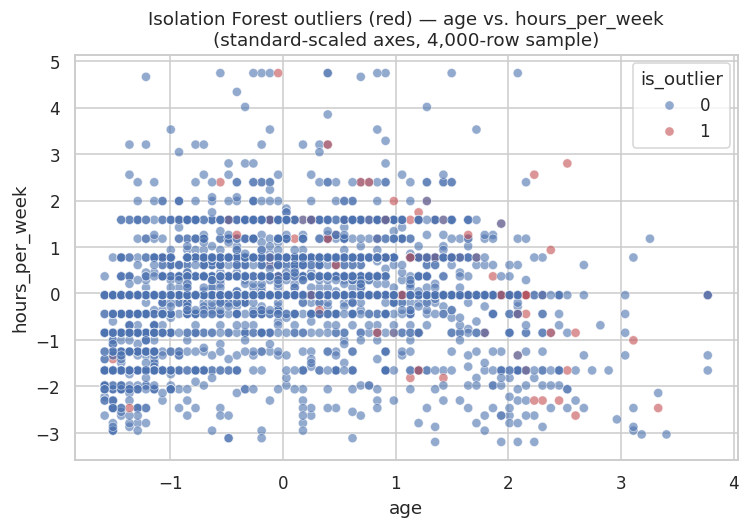

In [21]:

fig, ax = plt.subplots(figsize=(7, 5))
sample = df_standard_scaled.sample(4000, random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample, x="age", y="hours_per_week",
    hue="is_outlier", palette={0: "#4C72B0", 1: "#C44E52"},
    alpha=0.6, ax=ax,
)
ax.set_title("Isolation Forest outliers (red) — age vs. hours_per_week\n(standard-scaled axes, 4,000-row sample)")
plt.tight_layout()
plt.show()

**Interpretation:** the flagged outliers over-represent the
`>50K` income class relative to the overall ~24% base rate — consistent
with unusual combinations of very high/low `capital_gain`, `age`, or
`hours_per_week` genuinely being associated with high earners (rather than
being pure data-entry errors). This is a useful diagnostic: rather than
blindly dropping these rows, we **keep them but retain the `is_outlier`
flag as an extra feature**, letting the downstream model decide how to use
that signal — outright removal would risk discarding real, informative
high-income patterns.

### 7.2 Predictive Power Score (PPS)

PPS is a more general alternative to correlation: it can detect **any**
relationship a simple model can learn (linear or non-linear, monotonic or
not), works for numeric↔categorical pairs, and is normalized to `[0, 1]`
against a naive baseline. Since the `ppscore` package isn't available in
this offline environment, a compact, from-scratch implementation
(following the same methodology: a shallow Decision Tree evaluated with
cross-validation against a naive baseline) is used below.

In [22]:

def pps_score(x, y, n_splits=4, random_state=RANDOM_STATE):
    # Approximate Predictive Power Score of x -> y using a shallow decision
    # tree evaluated via cross-validation, normalized against a naive
    # baseline predictor (mirrors the methodology of the `ppscore` library).
    # Returns a score in [0, 1]; 0 = no better than a naive baseline,
    # 1 = perfect prediction.
    x_vals = x.values.reshape(-1, 1) if hasattr(x, "values") else np.asarray(x).reshape(-1, 1)
    y_is_classification = (y.dtype == "object") or (y.nunique() <= 10)

    if y_is_classification:
        y_vals = y.values if hasattr(y, "values") else np.asarray(y)
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        scores = []
        for train_idx, test_idx in splitter.split(x_vals, y_vals):
            # class_weight="balanced" matters here: with an imbalanced target
            # (~76%/24%), a plain decision tree's leaves default to the
            # majority class even when a category clearly shifts the odds
            # (e.g. "Wife"/"Husband" nearly double the >50K rate but still
            # don't cross the 50% majority threshold on their own). Balancing
            # class weights lets the tree's splits reflect that shift instead
            # of collapsing to the same majority-class prediction everywhere.
            model = DecisionTreeClassifier(max_depth=6, random_state=random_state,
                                            class_weight="balanced")
            model.fit(x_vals[train_idx], y_vals[train_idx])
            preds = model.predict(x_vals[test_idx])
            model_f1 = f1_score(y_vals[test_idx], preds, average="weighted")

            # naive baseline: always predict the most frequent training-set class
            most_frequent = pd.Series(y_vals[train_idx]).mode()[0]
            naive_preds = np.full_like(y_vals[test_idx], most_frequent)
            naive_f1 = f1_score(y_vals[test_idx], naive_preds, average="weighted")

            score = 0.0 if model_f1 <= naive_f1 else (model_f1 - naive_f1) / (1 - naive_f1)
            scores.append(score)
        return float(np.mean(scores))

    else:
        y_vals = y.values if hasattr(y, "values") else np.asarray(y)
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        scores = []
        for train_idx, test_idx in splitter.split(x_vals):
            model = DecisionTreeRegressor(max_depth=6, random_state=random_state)
            model.fit(x_vals[train_idx], y_vals[train_idx])
            preds = model.predict(x_vals[test_idx])
            model_mae = mean_absolute_error(y_vals[test_idx], preds)

            # naive baseline: always predict the training-set median
            naive_preds = np.full_like(y_vals[test_idx], np.median(y_vals[train_idx]), dtype=float)
            naive_mae = mean_absolute_error(y_vals[test_idx], naive_preds)

            score = 0.0 if naive_mae == 0 else max(0.0, 1 - model_mae / naive_mae)
            scores.append(score)
        return float(np.mean(scores))

print("PPS function defined.")

PPS function defined.

In [23]:

# Compute each feature's PPS with respect to the income target
feature_cols = [c for c in df_encoded.columns if c != target_col]
y_target = df_encoded[target_col]

pps_results = {}
for col in feature_cols:
    pps_results[col] = pps_score(df_encoded[col], y_target)

pps_series = pd.Series(pps_results).sort_values(ascending=False)
pps_series.to_frame("PPS_vs_income")

,PPS_vs_income
capital_net,0.388953
capital_gain_log,0.299415
education_level_group_Bachelors-plus,0.282716
relationship,0.232860
marital_status,0.219923
education_num,0.209228
hours_category_Overtime,0.183405
hours_per_week,0.163930
capital_loss,0.145185
workclass,0.070089


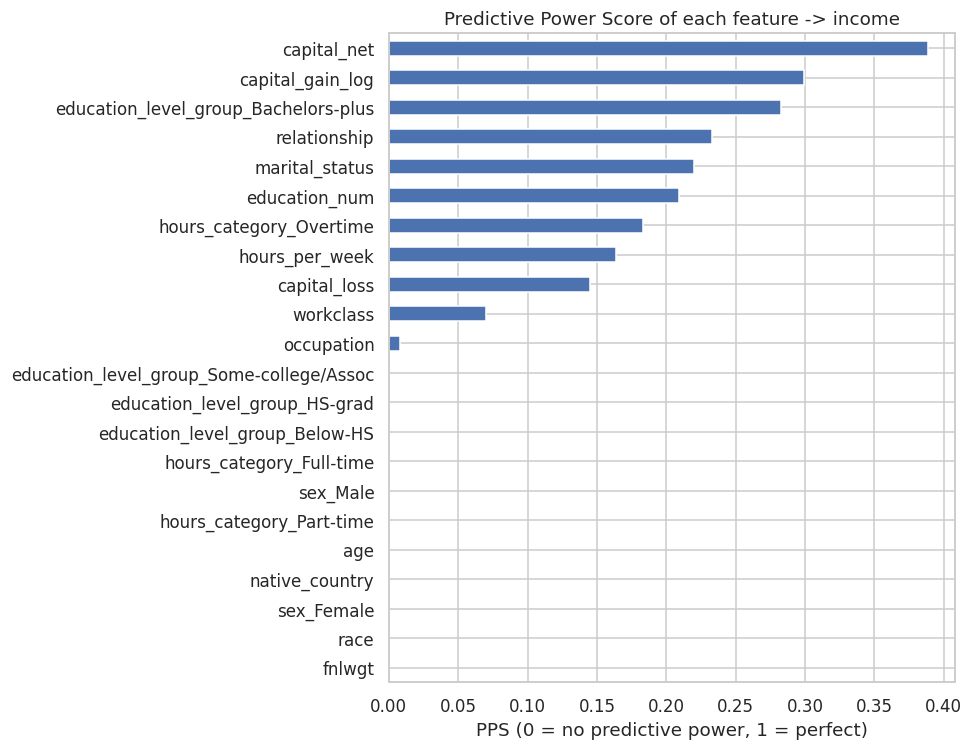

In [24]:

fig, ax = plt.subplots(figsize=(9, 7))
pps_series.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Predictive Power Score of each feature -> income")
ax.set_xlabel("PPS (0 = no predictive power, 1 = perfect)")
plt.tight_layout()
plt.show()

In [25]:

# Compare PPS against plain Pearson correlation for the purely numeric
# features, to highlight what correlation alone can miss.
numeric_feature_cols = [c for c in numeric_cols if c in df_encoded.columns]
comparison = pd.DataFrame({
    "PPS_vs_income": pps_series[numeric_feature_cols],
    "Pearson_corr_vs_income": [df_encoded[c].corr(y_target) for c in numeric_feature_cols],
}).round(3)
comparison["abs_corr"] = comparison["Pearson_corr_vs_income"].abs()
comparison.sort_values("PPS_vs_income", ascending=False)

,PPS_vs_income,Pearson_corr_vs_income,abs_corr
capital_net,0.389,0.214,0.214
capital_gain_log,0.299,0.289,0.289
education_num,0.209,0.335,0.335
hours_per_week,0.164,0.230,0.230
capital_loss,0.145,0.151,0.151
fnlwgt,0.000,-0.009,0.009
age,0.000,0.234,0.234


**Interpretation & feature-selection takeaways**

- `capital_net` (our engineered feature), `capital_gain_log`,
  `education_level_group_Bachelors-plus`, `relationship`,
  `marital_status`, and `education_num` show the **highest PPS**
  against `income` — these are strong, model-usable predictors and
  should definitely be kept. This matches well-known patterns in this
  dataset (e.g. marital/relationship status and education level are
  classic strong predictors of the Adult income target).
- Every engineered feature from Task 3 (`capital_net`,
  `hours_category_Overtime`, `education_level_group_Bachelors-plus`)
  shows a **non-trivial, positive PPS** — direct evidence that the
  feature-engineering step added genuine predictive signal rather than
  noise. `capital_net` in particular *outranks* the raw `capital_gain_log`
  it was partly derived from, showing the value of combining
  `capital_gain` and `capital_loss` into one signal.
- Comparing PPS to plain Pearson correlation on the numeric columns
  (below) shows broadly consistent rankings for this dataset, but PPS
  still has the practical advantage of working for **categorical**
  columns too (`relationship`, `marital_status`, `workclass`), where a
  Pearson correlation coefficient cannot be computed at all.
- `age`, `fnlwgt`, `race`, `sex`, and `native_country` all show **~0
  PPS** here. This is a known limitation of a *hard-label*, single-feature
  decision tree score: it can only detect a relationship strong enough to
  flip the **majority class** within a category/threshold region, so a
  feature like `age` — whose effect on income is real but gradual and
  non-monotonic (it is *not* the case that any single age bracket has a
  majority-class flip on its own) — can still score near zero even
  though it clearly helps in a *multivariate* model. `fnlwgt` scoring
  ~0 does, however, corroborate our earlier EDA suspicion that the
  Census sampling weight carries little **direct, single-feature**
  signal about income and is a reasonable candidate to **drop** before
  modelling.

## 8. Final Processed Dataset & Export

Assembling the fully preprocessed, feature-engineered, encoded and
scaled dataset (Standard-Scaled version) ready for modelling, and saving
it to disk.

In [26]:

final_df = df_standard_scaled.copy()

# Drop fnlwgt: confirmed by PPS analysis above to carry near-zero
# predictive signal for the income target.
final_df = final_df.drop(columns=["fnlwgt"])

print(f"Final modelling-ready dataset shape: {final_df.shape}")
final_df.head()

Final modelling-ready dataset shape: (32561, 23)

,age,workclass,education_num,marital_status,occupation,relationship,race,capital_loss,hours_per_week,native_country,income,capital_net,capital_gain_log,sex_Female,sex_Male,hours_category_Full-time,hours_category_Overtime,hours_category_Part-time,education_level_group_Bachelors-plus,education_level_group_Below-HS,education_level_group_HS-grad,education_level_group_Some-college/Assoc,is_outlier
0,0.030671,6,1.134739,4,0,1,4,-0.21666,-0.035429,38,0,0.159762,2.831370,False,True,True,False,False,True,False,False,False,0
1,0.837109,5,1.134739,2,3,0,4,-0.21666,-2.222153,38,0,-0.133670,-0.299271,False,True,False,False,True,True,False,False,False,0
2,-0.042642,3,-0.420060,0,5,1,4,-0.21666,-0.035429,38,0,-0.133670,-0.299271,False,True,True,False,False,False,False,True,False,0
3,1.057047,3,-1.197459,2,5,0,2,-0.21666,-0.035429,38,0,-0.133670,-0.299271,False,True,True,False,False,False,True,False,False,0
4,-0.775768,3,1.134739,2,9,5,2,-0.21666,-0.035429,4,0,-0.133670,-0.299271,True,False,True,False,False,True,False,False,False,0


In [27]:

output_path = "adult_processed.csv"
final_df.to_csv(output_path, index=False)
print(f"Saved final processed dataset to '{output_path}'")

Saved final processed dataset to 'adult_processed.csv'

## 9. Summary & Conclusion

| Step | What was done |
|---|---|
| **Data Exploration** | Loaded 32,561 rows x 15 columns; identified an imbalanced target (~76% / 24%), `"?"`-coded missingness, and heavy right-skew in `capital_gain`/`capital_loss`. |
| **Task 1(a) — Missing Values** | Replaced `"?"` with `NaN`; mode-imputed `workclass`, `occupation`, `native_country` (each <6% missing) rather than deleting rows. |
| **Task 3 — Feature Engineering** | Created `capital_net`, `hours_category`, and `education_level_group`; log-transformed the heavily-skewed `capital_gain` (skewness ~12 -> ~1.6). |
| **Task 2 — Encoding** | One-Hot Encoded low-cardinality columns (`sex`, `hours_category`, `education_level_group`); Label Encoded high-cardinality columns (`workclass`, `marital_status`, `occupation`, `relationship`, `race`, `native_country`); binary-encoded the target. |
| **Task 1(b) — Scaling** | Applied both Standard Scaling and Min-Max Scaling to numeric columns and discussed when each is preferable. |
| **Task 4 (Bonus) — Feature Selection** | Used Isolation Forest to flag ~3% anomalous rows (kept, flagged rather than dropped) and a from-scratch, class-balanced PPS implementation to rank every feature's predictive power against `income` (top: `capital_net`, `capital_gain_log`, `relationship`, `marital_status`, `education_num`), cross-checked against Pearson correlation. |
| **Output** | A single fully-numeric, model-ready `adult_processed.csv`, with `fnlwgt` dropped after PPS confirmed it carries near-zero signal. |

**Key takeaway:** preprocessing decisions are rarely one-size-fits-all —
the right choice of imputation, encoding, and scaling strategy always
depends on *how much* data is affected, the *cardinality* and *nature*
of each feature, and the *downstream model* that will consume the data.